In [ ]:

import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns



from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import (
    Tokenizer
)

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

SEED = 42





In [ ]:

#Xử lý các review
import html
import re
def data_processing(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Xóa các biến thể của <br>
    text = re.sub(r'<br\s*/?>', '', text)

    # Xóa HTML tag còn lại
    text = re.sub(r'<[^>]+>', '', text)

    # Xóa URL
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ', text
    )

    # Giữ chữ, số, khoảng trắng và dấu nháy đơn
    text = re.sub( r"[^a-z0-9\s']",' ',text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    return text




In [3]:
import pandas as pd

train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

x_train = train_df["clean_review"].astype(str)
y_train = train_df["label"].astype("int32")

x_val = validation_df["clean_review"].astype(str)
y_val = validation_df["label"].astype("int32")

x_test = test_df["clean_review"].astype(str)
y_test = test_df["label"].astype("int32")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (34703, 2)
Validation: (7437, 2)
Test: (7437, 2)


In [4]:
MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(x_train)

X_train = tokenizer.texts_to_sequences(x_train)
X_val = tokenizer.texts_to_sequences(x_val)
X_test = tokenizer.texts_to_sequences(x_test)

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )
]

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6622 - loss: 0.5576 - precision: 0.6615 - recall: 0.6364
Epoch 1: val_loss improved from None to 0.30854, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7769 - loss: 0.4366 - precision: 0.7769 - recall: 0.7793 - val_accuracy: 0.8720 - val_loss: 0.3085 - val_precision: 0.8353 - val_recall: 0.9279 - learning_rate: 0.0010
Epoch 2/30
538/543 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9190 - loss: 0.2149 - precision: 0.9164 - recall: 0.9243
Epoch 2: val_loss improved from 0.30854 to 0.27507, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9174 - loss: 0.2158 - precision: 0.9149 - recall: 0.9210 - val_accuracy: 0.8850 - val_loss: 0.2751 - val_precision: 0.8795 - val_recall: 0.8934 - learning_rate: 0.0010
Epoch 3/30
541/543 ━━━━━━━━━━━━━━━

In [9]:
loss, acc, precision, recall = model.evaluate(X_test, y_test)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8888 - loss: 0.2625 - precision: 0.8823 - recall: 0.8982
Accuracy : 0.8888
Precision: 0.8823
Recall   : 0.8982


In [10]:
from sklearn.metrics import classification_report

pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, pred))

233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      3705
           1       0.88      0.90      0.89      3732

    accuracy                           0.89      7437
   macro avg       0.89      0.89      0.89      7437
weighted avg       0.89      0.89      0.89      7437



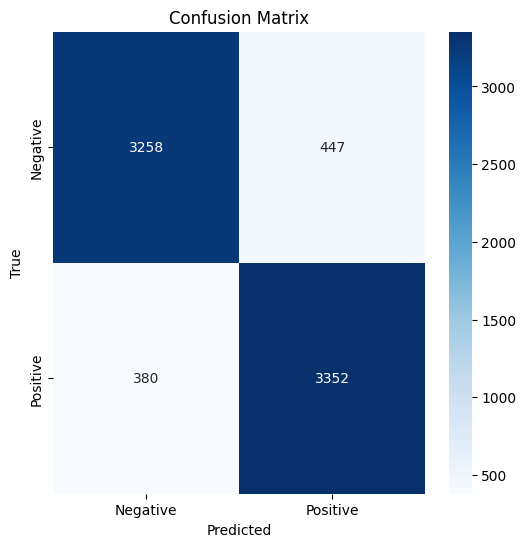

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

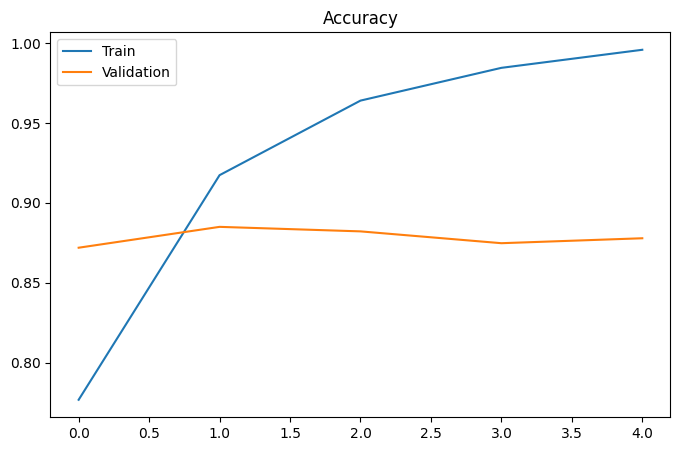

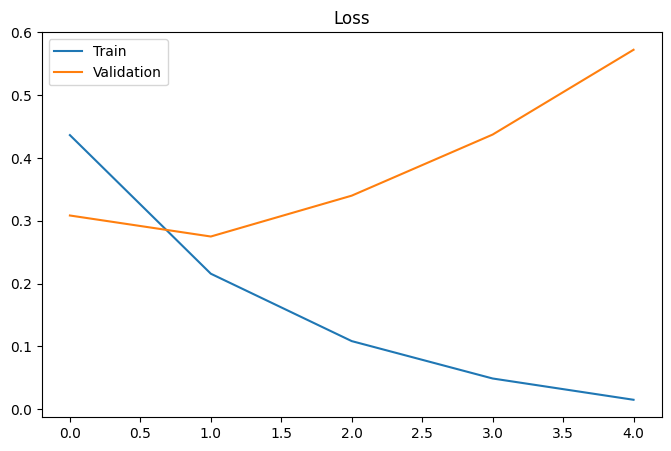

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")
plt.show()

In [13]:
sample = [
    "This movie was amazing. I loved every minute."
]

sample = tokenizer.texts_to_sequences(sample)
sample = pad_sequences(
    sample,
    maxlen=MAX_LEN,
    padding='post'
)

prediction = model.predict(sample)

print(prediction)

if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
[[0.9924627]]
Positive


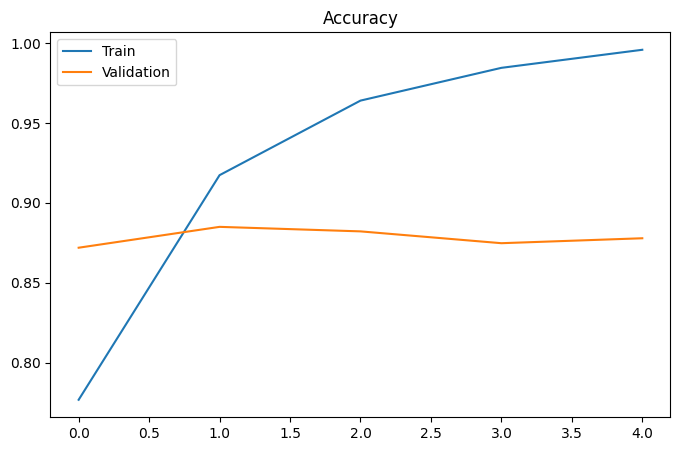

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")
plt.show()

